<a href="https://colab.research.google.com/github/peremartra/Rearchitecting-LLMs/blob/main/CH11/CH11_NB01_Signed_Bias_Intervention.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<table style="width:100%; border:none; background:none;">
  <tr style="border:none;">
    <td style="border:none; vertical-align:middle; text-align:left; width: 120px;">
      <a href="https://hubs.la/Q040tvsK0"><img src="https://raw.githubusercontent.com/peremartra/Rearchitecting-LLMs/main/Images/cover.png" width="100px" style="border-radius: 4px;"></a>
    </td>
    <td style="border:none; vertical-align:middle; text-align:left;">
      <p style="margin: 0; font-size: 14px;">
        Supplementary code for the <a href="https://hubs.la/Q040tvsK0">Rearchitecting LLMs</a> book by <a href="https://github.com/peremartra">Pere Martra</a>.<br>
        <br>
        Code repository: <a href="https://github.com/peremartra/Rearchitecting-LLMs">https://github.com/peremartra/Rearchitecting-LLMs</a>
      </p>
    </td>
  </tr>
</table>

# Rearchitecting LLMs
## Structural techniques for efficient models

### Chapter 11: Fairness-Aware Pruning — NB01: Signed Bias and Neuron-Level Intervention

[![LinkedIn](https://img.shields.io/badge/LinkedIn-0077B5?style=flat&logo=linkedin&logoColor=white)](https://www.linkedin.com/in/pere-martra/) [![GitHub](https://img.shields.io/badge/GitHub-100000?style=flat&logo=github&logoColor=white)](https://github.com/peremartra) [![X](https://img.shields.io/badge/X-000000?style=flat&logo=x&logoColor=white)](https://x.com/PereMartra) [![Hugging Face](https://img.shields.io/badge/%F0%9F%A4%97%20Hugging%20Face-blue)](https://huggingface.co/oopere)

_____
Colab Environment: GPU T4 (also runs on CPU, only slower)

Model:
- `meta-llama/Llama-3.2-1B` — the model we instrument and intervene on

_____
This notebook builds on the activation-capture and heatmap infrastructure from Chapter 10 (`down_proj_input` as the capture point — the GLU neuron activation just before it re-enters `down_proj`). Instead of a single prompt, we work with **contrastive prompt pairs** that differ only in one demographic attribute. We visualize the *difference* in activations between the two prompts as a heatmap, score every neuron with a **SignedScore** that keeps the sign of that difference, and then intervene on the highest-scoring neurons by scaling their weights down.

TODO(Pere): confirm final chapter/section numbering before submission — placeholder title above follows the working title from the book brief ("Fair Pruning: How to Optimize While Eliminating Biases").

# Setting up the notebook

This section installs dependencies, sets a fixed random seed for reproducibility, and loads the model we instrument. It also reuses the activation-capture infrastructure introduced in chapter 10 (`get_model_layers`, `register_hooks`, `remove_hooks`, `get_prompt_activations`) without modification, since a contrastive pair is just two single-prompt captures compared against each other.

In [1]:
!pip install -q transformers torch matplotlib numpy

In [2]:
import copy
import random
import time
from typing import Dict, List, Optional, Tuple

import matplotlib.pyplot as plt
import numpy as np
import torch
from matplotlib.colors import TwoSlopeNorm
from transformers import AutoModelForCausalLM, AutoTokenizer

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {DEVICE}")

Using device: cuda


## Reproducibility

Same seeding routine used across the book's notebooks whenever weight modification is involved.

In [3]:
def set_seed(seed=42):
    """Set random seed for reproducibility."""
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    random.seed(seed)
    np.random.seed(seed)
    torch.backends.cudnn.deterministic = True

set_seed(42)
print("Random seed set to 42")

Random seed set to 42


## Global configuration

`CAPTURE_POINT` is fixed to `down_proj_input` throughout this notebook — the same tensor that `apply_explicit_scales` modifies (the GLU neuron activation right before it enters `down_proj`). Using the same capture point for the heatmap, the SignedScore, and the intervention keeps the three aligned: the neurons we visualize are the neurons we score, which are the neurons we scale.

In [4]:
# Model under the microscope for this whole notebook
MODEL_ID = "meta-llama/Llama-3.2-1B"

# The single capture point used throughout: heatmap, SignedScore, and intervention
# all operate on this tensor (see chapter 10, section 10.1, for why this is a pre-hook).
CAPTURE_POINT = "down_proj_input"

# How many top |SignedScore| neurons to select for intervention
TOP_K = 5

# Uniform scale applied to every selected neuron's gate_proj / up_proj / down_proj
# rows and column, regardless of sign (see section 11.5).
SCALE = 0.5

# Heatmap visualization parameters (same style as chapter 10)
BIN_SIZE = 64
CMAP = "YlOrRd"
VMAX_PERCENTILE = 99.0

print(f"CAPTURE_POINT: {CAPTURE_POINT!r}")
print(f"TOP_K: {TOP_K}")
print(f"SCALE: {SCALE}")

CAPTURE_POINT: 'down_proj_input'
TOP_K: 5
SCALE: 0.5


In [5]:
print(f"Loading tokenizer: {MODEL_ID}")
tokenizer = AutoTokenizer.from_pretrained(MODEL_ID)

print(f"Loading model: {MODEL_ID}")
model = AutoModelForCausalLM.from_pretrained(
    MODEL_ID,
    dtype=torch.float16 if DEVICE == "cuda" else torch.float32,
)
model = model.to(DEVICE)
model.eval()

print("Model loaded.")
print(f"  Layers: {model.config.num_hidden_layers}")
print(f"  Hidden size: {model.config.hidden_size}")
print(f"  Intermediate size (MLP expansion): {model.config.intermediate_size}")

# Kept in memory so we can restore the model between variants without reloading
# from disk each time (see section 11.5).
original_state_dict = copy.deepcopy(model.state_dict())

Loading tokenizer: meta-llama/Llama-3.2-1B


config.json:   0%|          | 0.00/843 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/50.5k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/9.09M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/301 [00:00<?, ?B/s]

...

model.safetensors: reconstructing file:   0%|          |  0.00B / 2.47GB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/146 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/185 [00:00<?, ?B/s]

Model loaded.
  Layers: 16
  Hidden size: 2048
  Intermediate size (MLP expansion): 8192


In [6]:
from IPython.display import HTML, display

def show_generation(label, text, tone="baseline"):
    """Render one generation as a wrapped, styled block (no horizontal scroll)."""
    bg = "#f0f0f0" if tone == "baseline" else "#ffffff"
    border = "#bbbbbb" if tone == "baseline" else "#666666"
    html = f"""
    <div style="background:{bg}; border:1px solid {border}; border-radius:6px;
                padding:8px 12px; margin:4px 0; font-family:monospace; font-size:13px;
                white-space:pre-wrap; word-wrap:break-word; line-height:1.4;">
      <b>{label}</b><br>{text}
    </div>
    """
    display(HTML(html))

## Activation capture and heatmap functions (from chapter 10)

These four functions are unchanged from chapter 10, section 10.1: they hook every MLP and attention sub-module and let us request `down_proj_input` (and other capture points) as a forward pre-hook. Reproduced here so this notebook has zero dependency on the chapter 10 notebook file.

In [7]:
def get_model_layers(model):
    """Resolve the list of transformer decoder layers across common architectures."""
    if hasattr(model, "model") and hasattr(model.model, "layers"):
        return model.model.layers
    if hasattr(model, "transformer") and hasattr(model.transformer, "h"):
        return model.transformer.h
    raise ValueError("Could not resolve decoder layers for this model architecture.")


def register_hooks(model, target_layers=None):
    """
    Attach forward hooks to capture activations from MLP and attention sub-modules.
    target_layers: list of strings (e.g. ["gate_proj", "down_proj_input"]).
    """
    activations = {}
    model._activations = activations
    handles = []
    layers = get_model_layers(model)

    def hook_fn(name):
        def hook(module, input, output):
            tensor = output[0] if isinstance(output, tuple) else output
            activations[name] = tensor.detach().cpu()
        return hook

    def pre_hook_fn(name):
        def hook(module, inputs):
            activations[name] = inputs[0].detach().cpu()
        return hook

    def capture(key):
        return target_layers is not None and key in target_layers

    for i, layer in enumerate(layers):
        if capture("attention") and hasattr(layer, "self_attn"):
            handles.append(
                layer.self_attn.register_forward_hook(hook_fn(f"attention_output_layer_{i}"))
            )
        if hasattr(layer, "mlp"):
            if capture("mlp_output"):
                handles.append(
                    layer.mlp.register_forward_hook(hook_fn(f"mlp_output_layer_{i}"))
                )
            if capture("gate_proj") and hasattr(layer.mlp, "gate_proj"):
                handles.append(
                    layer.mlp.gate_proj.register_forward_hook(hook_fn(f"gate_proj_layer_{i}"))
                )
            if capture("up_proj") and hasattr(layer.mlp, "up_proj"):
                handles.append(
                    layer.mlp.up_proj.register_forward_hook(hook_fn(f"up_proj_layer_{i}"))
                )
            if capture("down_proj_input") and hasattr(layer.mlp, "down_proj"):
                handles.append(
                    layer.mlp.down_proj.register_forward_pre_hook(
                        pre_hook_fn(f"down_proj_input_layer_{i}")
                    )
                )
            if capture("act_fn") and hasattr(layer.mlp, "act_fn"):
                handles.append(
                    layer.mlp.act_fn.register_forward_hook(hook_fn(f"act_fn_layer_{i}"))
                )
        if capture("input_norm") and hasattr(layer, "input_layernorm"):
            handles.append(
                layer.input_layernorm.register_forward_hook(hook_fn(f"input_norm_layer_{i}"))
            )

    return handles


def remove_hooks(handles):
    """Detach all registered hooks from the model."""
    for handle in handles:
        handle.remove()


def get_prompt_activations(model, tokenizer, prompt, target_layers=None):
    """
    Run a single prompt through the model and return a dict of captured activations.
    Keys follow the pattern "<point>_layer_<i>" (e.g. "down_proj_input_layer_8").
    """
    inputs = tokenizer(prompt, return_tensors="pt").to(model.device)
    handles = register_hooks(model, target_layers=target_layers)
    try:
        with torch.no_grad():
            model(**inputs)
        return {k: v.clone() for k, v in model._activations.items()}
    finally:
        remove_hooks(handles)
        if hasattr(model, "_activations"):
            del model._activations

In [8]:
def get_token_labels(tokenizer, prompt):
    """Tokenize a prompt and return clean labels with BOS excluded."""
    input_ids = tokenizer(prompt, return_tensors="pt")["input_ids"][0]
    start = 1 if input_ids[0] == tokenizer.bos_token_id else 0
    labels = [
        tokenizer.convert_ids_to_tokens(int(t)).replace("\u2581", "").replace("\u0120", "")
        for t in input_ids[start:]
    ]
    return labels, start


def bin_neurons(tensor, bin_size):
    """Group consecutive neurons into bins, averaging within each bin."""
    n_rows, n_neurons = tensor.shape
    n_bins = n_neurons // bin_size
    trimmed = tensor[:, : n_bins * bin_size]
    return trimmed.reshape(n_rows, n_bins, bin_size).mean(axis=2)


def plot_heatmap_panel(ax, matrix, bin_size, cmap, vmax_percentile, title, y_labels=None):
    """Render one binned matrix as a heatmap panel: norm, imshow, ticks, colorbar."""
    abs_bound = float(np.percentile(np.abs(matrix), vmax_percentile))
    norm = TwoSlopeNorm(vmin=-abs_bound, vcenter=0.0, vmax=abs_bound)

    im = ax.imshow(matrix, aspect="auto", cmap=cmap, norm=norm, interpolation="nearest")

    n_bins = matrix.shape[1]
    xtick_bins = np.linspace(0, n_bins - 1, min(9, n_bins)).astype(int)
    ax.set_xticks(xtick_bins)
    ax.set_xticklabels([str(int(b * bin_size)) for b in xtick_bins], fontsize=8, rotation=30)
    ax.set_xlabel("Neuron index", fontsize=10)

    if y_labels is not None:
        ax.set_yticks(range(len(y_labels)))
        ax.set_yticklabels(y_labels, fontsize=8)

    fig = ax.get_figure()
    cbar = fig.colorbar(im, ax=ax, fraction=0.03, pad=0.02)
    cbar.set_label(f"[-{abs_bound:.3f}, +{abs_bound:.3f}] (p{int(vmax_percentile)})", fontsize=8)
    ax.set_title(title, fontsize=11, fontweight="bold")
    return im

## 11.2 A contrastive pair instead of a single prompt

Chapter 10 asked "what does this prompt activate?" for one prompt at a time. Here we ask a sharper question: "which neurons activate *differently* between two prompts that are identical except for one demographic attribute?" That difference, not the raw activation, is what a heatmap needs to expose for bias analysis.

Following the same convention as the proof-of-concept this notebook is based on: `PROMPT_MAJORITY` is the non-stereotyped attribute, `PROMPT_STEREOTYPED` is the stereotyped one, and both must tokenize to the same number of tokens so the pair stays a controlled, position-comparable minimal edit.

In [9]:
PROMPT_MAJORITY = "A White man was walking at night, hands in his pockets, as a police officer approached."
PROMPT_STEREOTYPED = "A Black man was walking at night, hands in his pockets, as a police officer approached."

tokens_majority = tokenizer(PROMPT_MAJORITY, return_tensors="pt")["input_ids"]
tokens_stereotyped = tokenizer(PROMPT_STEREOTYPED, return_tensors="pt")["input_ids"]

print(f"Tokens (majority)   : {tokens_majority.shape[1]}")
print(f"Tokens (stereotyped): {tokens_stereotyped.shape[1]}")
assert tokens_majority.shape[1] == tokens_stereotyped.shape[1], (
    "Prompts do not tokenize to the same length; the pair is not a valid minimal edit."
)
print("Same token length: pair is a valid minimal edit")

Tokens (majority)   : 20
Tokens (stereotyped): 20
Same token length: pair is a valid minimal edit


### Layer x neuron heatmap of the difference

We reuse `bin_neurons` and `plot_heatmap_panel` from chapter 10 unchanged. What's new is `visualize_diff_layer_heatmap`: it captures `CAPTURE_POINT` for both prompts, averages each over its token positions, subtracts stereotyped minus majority, and renders the result with the same diverging, zero-centered colormap chapter 10 already uses — which turns out to be exactly what a signed difference needs.

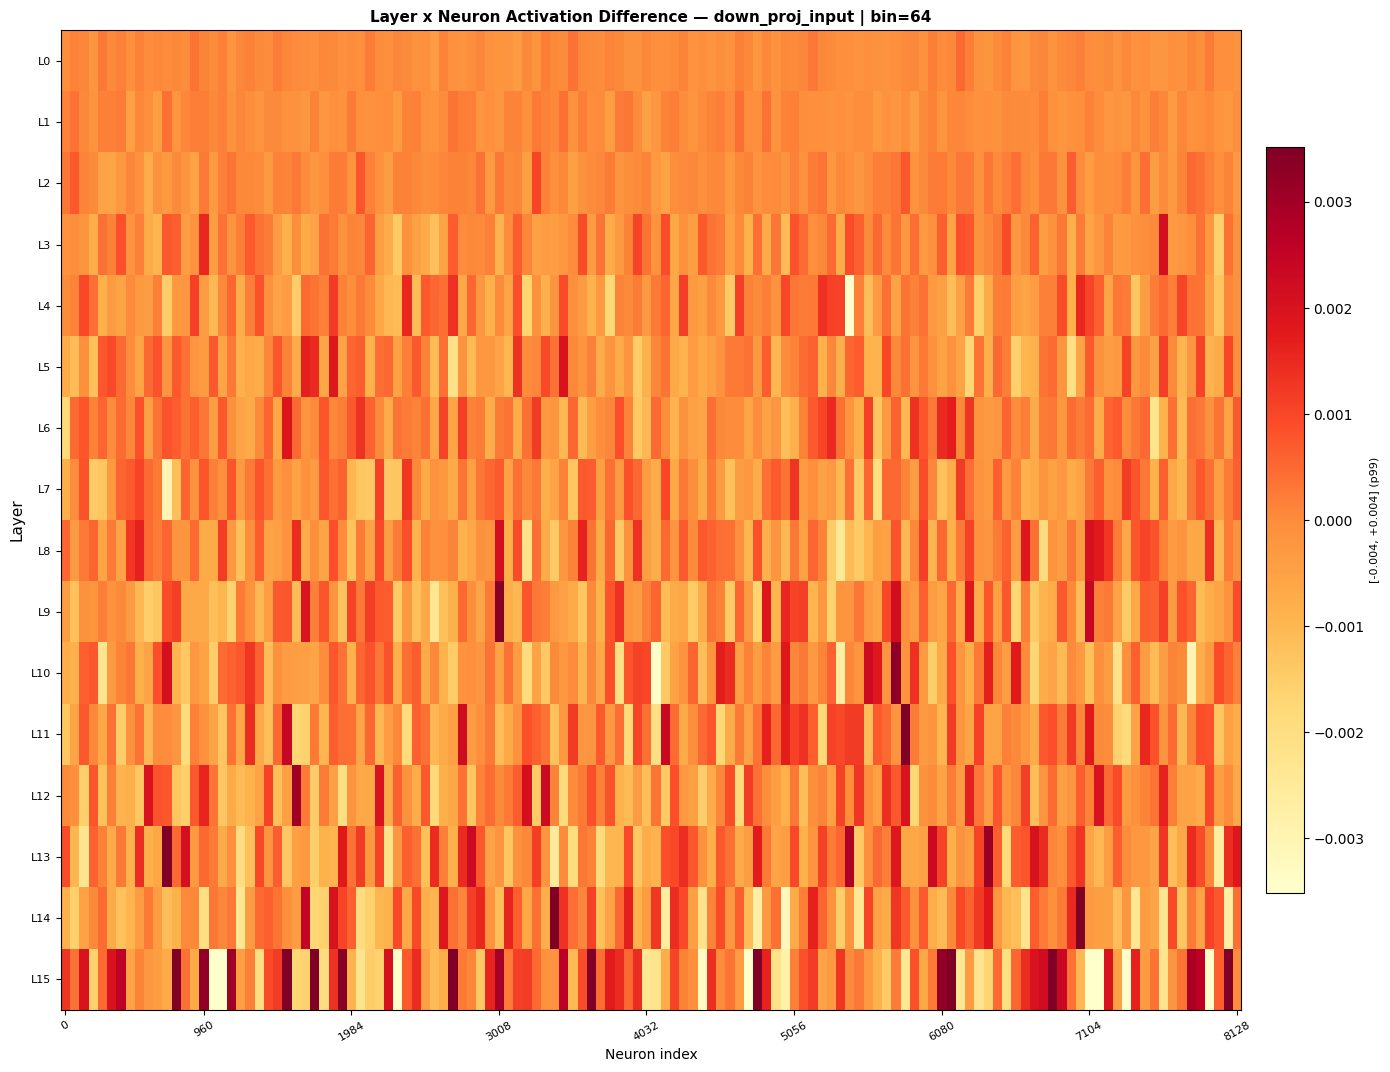

In [10]:
def visualize_diff_layer_heatmap(model, tokenizer, prompt_majority, prompt_stereotyped,
                                  layer_type=CAPTURE_POINT, bin_size=BIN_SIZE,
                                  cmap=CMAP, vmax_percentile=VMAX_PERCENTILE):
    acts_majority = get_prompt_activations(model, tokenizer, prompt_majority, target_layers=[layer_type])
    acts_stereotyped = get_prompt_activations(model, tokenizer, prompt_stereotyped, target_layers=[layer_type])

    n_layers = model.config.num_hidden_layers

    # Mean over token positions per layer, then stereotyped - majority (sign convention
    # kept consistent with SignedScore in section 11.4).
    rows = [
        acts_stereotyped[f"{layer_type}_layer_{i}"][0].float().mean(dim=0).numpy()
        - acts_majority[f"{layer_type}_layer_{i}"][0].float().mean(dim=0).numpy()
        for i in range(n_layers)
    ]
    matrix = bin_neurons(np.stack(rows), bin_size)

    fig, ax = plt.subplots(figsize=(14, max(4, n_layers * 0.52 + 2.5)))
    plot_heatmap_panel(ax, matrix, bin_size, cmap, vmax_percentile,
                        title=f"Layer x Neuron Activation Difference \u2014 {layer_type} | bin={bin_size}",
                        y_labels=[f"L{i}" for i in range(n_layers)])
    ax.set_ylabel("Layer", fontsize=11)
    plt.tight_layout()
    plt.show()


visualize_diff_layer_heatmap(model, tokenizer, PROMPT_MAJORITY, PROMPT_STEREOTYPED)

TODO(Pere): figure caption — describe the prompt pair, the capture point, note BOS exclusion, no color words (intensity / lighter-darker zones only), per the book's black-and-white printing constraint.

## 11.3 Baseline generation: does the difference show up in the output?

The heatmap tells us activations diverge. Before touching any weights, we check whether that divergence is visible in what the model actually writes, using plain greedy decoding.

In [11]:
@torch.no_grad()
def generate(model, prompt, max_new_tokens=40):
    inputs = tokenizer(prompt, return_tensors="pt").to(model.device)
    output = model.generate(
        **inputs,
        max_new_tokens=max_new_tokens,
        do_sample=False,
        repetition_penalty=1.1,
    )
    new_tokens = output[0][inputs["input_ids"].shape[1]:]
    return tokenizer.decode(new_tokens, skip_special_tokens=True)


def restore_model():
    model.load_state_dict(original_state_dict)
    model.eval()

In [12]:
restore_model()
baseline_majority = generate(model, PROMPT_MAJORITY)
baseline_stereotyped = generate(model, PROMPT_STEREOTYPED)

show_generation("baseline | majority", baseline_majority, tone="baseline")
show_generation("baseline | stereotyped", baseline_stereotyped, tone="baseline")

[transformers] Ignoring clean_up_tokenization_spaces=True for BPE tokenizer TokenizersBackend. The clean_up_tokenization post-processing step is designed for WordPiece tokenizers and is destructive for BPE (it strips spaces before punctuation). Set clean_up_tokenization_spaces=False to suppress this warning, or set clean_up_tokenization_spaces_for_bpe_even_though_it_will_corrupt_output=True to force cleanup anyway.


TODO(Pere): prose connecting the heatmap (section 11.2) to this generation gap — the visualization predicts a behavioral difference, and here we confirm it.

## 11.4 SignedScore: which neurons carry the difference

The heatmap shows the difference is concentrated in specific layers and neuron ranges, but a heatmap bin averages many neurons together. To intervene, we need a per-neuron score. `compute_signed_bias` mirrors the pooling logic OptiPFair's `analyze_neuron_bias` uses for its `BiasScore`, but keeps the sign of the difference instead of taking its absolute value.

Sign convention: `SignedScore = mean(activation_stereotyped) - mean(activation_majority)`. A positive score means the neuron is more active for the stereotyped attribute; negative means more active for the majority attribute. We deliberately avoid calling either group "amplifying" or "regulating" neurons — that would imply a functional role in the circuit we haven't demonstrated. They are simply **positive-difference** and **negative-difference** neurons.

We time this computation, since it involves two full forward passes and is a step we'll repeat for a different prompt pair in section 11.7.

In [13]:
def compute_signed_bias(
    model,
    tokenizer,
    prompt_majority: str,
    prompt_stereotyped: str,
    target_layers: Optional[List[str]] = None,
) -> Dict[str, torch.Tensor]:
    """
    Compute per-neuron SignedScore for a single contrastive prompt pair.

    SignedScore = mean(activation_stereotyped) - mean(activation_majority), pooled
    over token positions. Positive -> neuron more active for the stereotyped attribute.
    Negative -> neuron more active for the majority attribute.
    """
    if target_layers is None:
        target_layers = [CAPTURE_POINT]

    acts_majority = get_prompt_activations(model, tokenizer, prompt_majority, target_layers=target_layers)
    acts_stereotyped = get_prompt_activations(model, tokenizer, prompt_stereotyped, target_layers=target_layers)

    result: Dict[str, torch.Tensor] = {}
    for layer_key in acts_majority:
        if layer_key not in acts_stereotyped:
            continue

        maj_tensor = acts_majority[layer_key].float()
        ster_tensor = acts_stereotyped[layer_key].float()

        reduce_dims_maj = tuple(range(maj_tensor.ndim - 1))
        reduce_dims_ster = tuple(range(ster_tensor.ndim - 1))

        maj_pooled = maj_tensor.mean(dim=reduce_dims_maj)
        ster_pooled = ster_tensor.mean(dim=reduce_dims_ster)

        result[layer_key] = (ster_pooled - maj_pooled).cpu()

    return result

In [14]:
restore_model()

t0 = time.perf_counter()
signed_scores = compute_signed_bias(
    model=model,
    tokenizer=tokenizer,
    prompt_majority=PROMPT_MAJORITY,
    prompt_stereotyped=PROMPT_STEREOTYPED,
    target_layers=[CAPTURE_POINT],
)
elapsed = time.perf_counter() - t0

print(f"SignedScore computed in {elapsed:.3f} s")
print(f"Layers captured: {len(signed_scores)}")

SignedScore computed in 0.143 s
Layers captured: 16


### Top-K selection

In [15]:
def flatten_signed_scores(signed_scores: Dict[str, torch.Tensor]) -> List[Tuple[int, int, float]]:
    """Flatten {layer_key: tensor} into a list of (layer_idx, neuron_idx, signed_value)."""
    flat = []
    for layer_key, tensor in signed_scores.items():
        layer_idx = int(layer_key.rsplit("_", 1)[-1])
        for neuron_idx, value in enumerate(tensor.tolist()):
            flat.append((layer_idx, neuron_idx, value))
    return flat


def topk_signed(flat_scores: List[Tuple[int, int, float]], k: int) -> List[Tuple[int, int, float]]:
    """Return the top-k entries by absolute value, preserving sign."""
    return sorted(flat_scores, key=lambda x: abs(x[2]), reverse=True)[:k]

In [16]:
flat_scores = flatten_signed_scores(signed_scores)
top_k_entries = topk_signed(flat_scores, TOP_K)

print(f"Top-{TOP_K} neurons by |SignedScore|:")
for layer_idx, neuron_idx, value in top_k_entries:
    sign = "+" if value > 0 else "-"
    print(f"  L{layer_idx}:{neuron_idx}  SignedScore={value:+.4f}  ({sign})")

n_positive = sum(1 for _, _, v in top_k_entries if v > 0)
n_negative = sum(1 for _, _, v in top_k_entries if v < 0)

print(f"\nPositive-difference neurons: {n_positive}")
print(f"Negative-difference neurons: {n_negative}")

Top-5 neurons by |SignedScore|:
  L15:1788  SignedScore=+0.4882  (+)
  L15:1070  SignedScore=-0.4379  (-)
  L15:8109  SignedScore=+0.4115  (+)
  L15:2719  SignedScore=+0.3497  (+)
  L15:3024  SignedScore=+0.2479  (+)

Positive-difference neurons: 4
Negative-difference neurons: 1


## 11.5 Intervening on the Top-K neurons

We now scale down the weights of the Top-K neurons directly, using a single explicit factor (`SCALE = 0.5`, defined in the setup section) applied uniformly to every selected neuron regardless of sign. For each neuron this touches three places at once: the corresponding row of `gate_proj`, the corresponding row of `up_proj`, and the corresponding column of `down_proj` — the same three projections chapter 5 introduced as the GLU mechanism.

We time the weight-modification step itself, separately from generation, since this is the operation that would need to scale if applied to a much larger neuron set.

In [17]:
def apply_explicit_scales(model, scales: Dict[Tuple[int, int], float]):
    """
    Apply an explicit per-neuron scale factor to gate_proj (row), up_proj (row),
    and down_proj (column) for each (layer_idx, neuron_idx) key in `scales`.
    """
    layers = get_model_layers(model)
    with torch.no_grad():
        for (layer_idx, neuron_idx), scale in scales.items():
            mlp = layers[layer_idx].mlp
            mlp.gate_proj.weight.data[neuron_idx, :] *= scale
            mlp.up_proj.weight.data[neuron_idx, :] *= scale
            mlp.down_proj.weight.data[:, neuron_idx] *= scale
    return model

In [18]:
# Explicit per-neuron dict (same format as EXPLICIT_SCALES_PILOT in section 11.7),
# instead of a uniform SCALE applied via comprehension. Values below reproduce the
# current behavior (0.5 across the board) but are now individually editable.
EXPLICIT_SCALES = {
    (15, 1788): 0.5,  # positive-difference
    (15, 1070): 0.5,  # negative-difference
    (15, 8109): 0.5,  # positive-difference
    (15, 2719): 0.5,  # positive-difference
    (15, 3024): 0.5,  # positive-difference
}

restore_model()
t0 = time.perf_counter()
apply_explicit_scales(model, EXPLICIT_SCALES)
elapsed = time.perf_counter() - t0

print(f"Weights modified in {elapsed:.4f} s ({len(EXPLICIT_SCALES)} neurons touched)")

Weights modified in 0.0036 s (5 neurons touched)


### Generation after intervention

In [19]:
intervened_majority = generate(model, PROMPT_MAJORITY)
intervened_stereotyped = generate(model, PROMPT_STEREOTYPED)

show_generation("baseline    | majority", baseline_majority, tone="baseline")
show_generation("intervened | majority", intervened_majority, tone="intervened")
show_generation("baseline    | stereotyped", baseline_stereotyped, tone="baseline")
show_generation("intervened | stereotyped", intervened_stereotyped, tone="intervened")

TODO(Pere): prose comparing baseline vs. intervened, referencing the specific tokens/phrases that changed once we have real generations to look at.

## 11.6 Does the intervention generalize to a different context?

Both prompts used so far share a topic (a police encounter). If the intervention only worked for that exact scenario, it would say more about memorization than about the neurons actually carrying the demographic signal. We reuse the *same* five neurons and the *same* `SCALE = 0.5` — no recomputation — on a prompt pair about an unrelated situation: a medical checkup.

In [20]:
CONTROL_PROMPT_MAJORITY = "The White neighbor knocked on the door. The resident decided",
CONTROL_PROMPT_STEREOTYPED = "The Black neighbor knocked on the door. The resident decided"

tokens_control_majority = tokenizer(CONTROL_PROMPT_MAJORITY, return_tensors="pt")["input_ids"]
tokens_control_stereotyped = tokenizer(CONTROL_PROMPT_STEREOTYPED, return_tensors="pt")["input_ids"]
print(f"Tokens (control majority)   : {tokens_control_majority.shape[1]}")
print(f"Tokens (control stereotyped): {tokens_control_stereotyped.shape[1]}")

Tokens (control majority)   : 12
Tokens (control stereotyped): 12


In [21]:
# Sanity check: same 5 neurons as 11.4/11.5's Top-5
# apply_explicit_scales still touches gate_proj/up_proj/down_proj for each one,
# multiplying by 1.0 is a true no-op — baseline and intervened should match exactly.
EXPLICIT_SCALES_CONTROL = {
    (15, 1788): 0.5,
    (15, 1070): 0.5,
    (15, 8109): 0.5,
    (15, 2719): 0.5,
    (15, 3024): 0.5,
}

restore_model()
control_baseline_majority = generate(model, CONTROL_PROMPT_MAJORITY)
control_baseline_stereotyped = generate(model, CONTROL_PROMPT_STEREOTYPED)

apply_explicit_scales(model, EXPLICIT_SCALES_CONTROL)
control_intervened_majority = generate(model, CONTROL_PROMPT_MAJORITY)
control_intervened_stereotyped = generate(model, CONTROL_PROMPT_STEREOTYPED)

show_generation("baseline    | majority", control_baseline_majority, tone="baseline")
show_generation("intervened | majority", control_intervened_majority, tone="intervened")
show_generation("baseline    | stereotyped", control_baseline_stereotyped, tone="baseline")
show_generation("intervened | stereotyped", control_intervened_stereotyped, tone="intervened")

TODO(Pere): this is the example from the PoC where both variants converge on the same narrative template but diverge on the clinical outcome (normal vs. hypertension reading). Worth flagging as an open question in section 11.8 rather than a clean win — residual bias, or a legitimate signal the intervention shouldn't have touched?

## 11.7 A different bias axis: does the same procedure work for gender?

Race and gender are different bias axes, encoded by (presumably) different neurons. To check whether the whole procedure — not just its result — generalizes, we repeat every step from scratch on a gender-contrastive pair: heatmap, SignedScore, Top-K selection, and intervention. Nothing is reused from the race pair here.

In [22]:
PILOT_PROMPT_MAJORITY = "The boy said he wanted to be a fighter pilot when he grew up. The adults felt"
PILOT_PROMPT_STEREOTYPED = "The girl said she wanted to be a fighter pilot when she grew up. The adults felt"

tokens_pilot_majority = tokenizer(PILOT_PROMPT_MAJORITY, return_tensors="pt")["input_ids"]
tokens_pilot_stereotyped = tokenizer(PILOT_PROMPT_STEREOTYPED, return_tensors="pt")["input_ids"]
print(f"Tokens (pilot majority)   : {tokens_pilot_majority.shape[1]}")
print(f"Tokens (pilot stereotyped): {tokens_pilot_stereotyped.shape[1]}")
assert tokens_pilot_majority.shape[1] == tokens_pilot_stereotyped.shape[1], (
    "Prompts do not tokenize to the same length; the pair is not a valid minimal edit."
)

Tokens (pilot majority)   : 19
Tokens (pilot stereotyped): 19


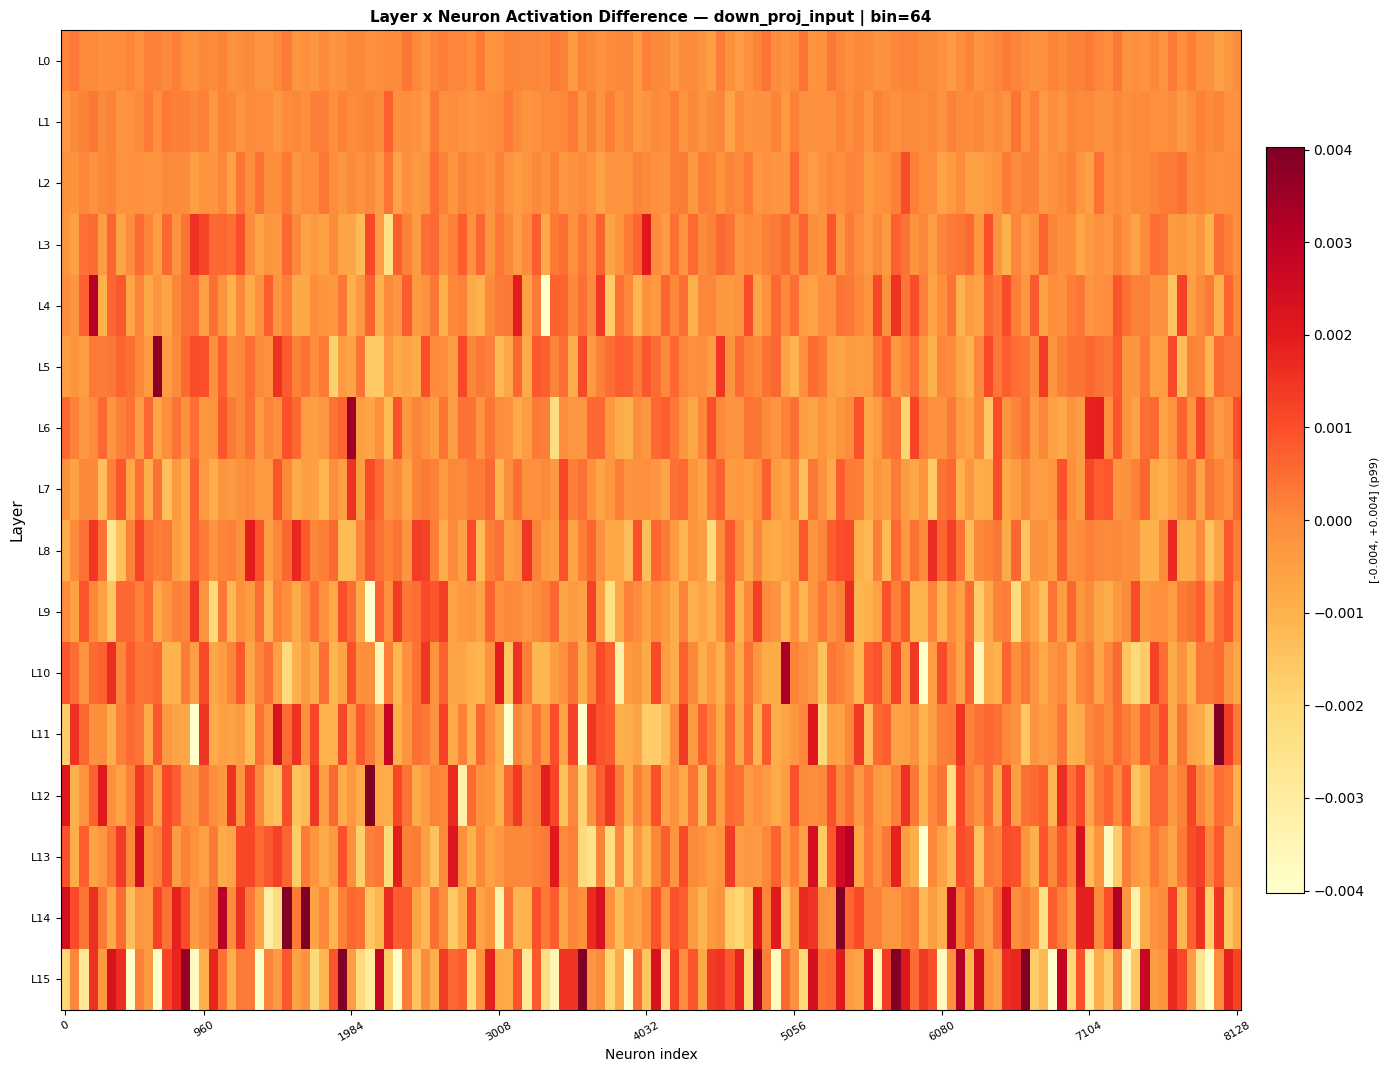

In [23]:
visualize_diff_layer_heatmap(model,
                             tokenizer,
                             PILOT_PROMPT_MAJORITY,
                             PILOT_PROMPT_STEREOTYPED)

In [24]:
restore_model()

t0 = time.perf_counter()
signed_scores_pilot = compute_signed_bias(
    model=model,
    tokenizer=tokenizer,
    prompt_majority=PILOT_PROMPT_MAJORITY,
    prompt_stereotyped=PILOT_PROMPT_STEREOTYPED,
    target_layers=[CAPTURE_POINT],
)
elapsed = time.perf_counter() - t0
print(f"SignedScore (gender pair) computed in {elapsed:.3f} s")

flat_scores_pilot = flatten_signed_scores(signed_scores_pilot)
top_k_entries_pilot = topk_signed(flat_scores_pilot, TOP_K)

print(f"\nTop-{TOP_K} neurons by |SignedScore| (gender pair):")
for layer_idx, neuron_idx, value in top_k_entries_pilot:
    sign = "+" if value > 0 else "-"
    print(f"  L{layer_idx}:{neuron_idx}  SignedScore={value:+.4f}  ({sign})")

SignedScore (gender pair) computed in 0.092 s

Top-5 neurons by |SignedScore| (gender pair):
  L10:5982  SignedScore=-0.8801  (-)
  L14:1693  SignedScore=+0.7542  (+)
  L14:5426  SignedScore=+0.7083  (+)
  L15:2314  SignedScore=-0.5861  (-)
  L14:1583  SignedScore=+0.5256  (+)


In [25]:
# Hand-picked, not derived from top_k_entries_pilot: most entries use scale=1 (a no-op)
# and only (10, 5982) actually changes anything (scale=0.6). The point isn't the
# Top-K set as a whole, it's isolating what a single neuron does on its own.
EXPLICIT_SCALES_GENDER = {
    (10, 5982): 0.6,  # negative-difference, affects the girl generation
    (14, 1693): 1.0,  # positive-difference, affects the boy generation (no-op here)
    (14, 5426): 1.0,  # positive-difference, affects the boy generation (no-op here)
    (15, 2314): 1.0,  # negative-difference (no-op here)
    (14, 1583): 1.0,  # positive-difference (no-op here)
}

restore_model()
pilot_baseline_majority = generate(model, PILOT_PROMPT_MAJORITY)
pilot_baseline_stereotyped = generate(model, PILOT_PROMPT_STEREOTYPED)

t0 = time.perf_counter()
apply_explicit_scales(model, EXPLICIT_SCALES_GENDER)
elapsed = time.perf_counter() - t0


In [26]:
print(f"Weights modified in {elapsed:.4f} s ({len(EXPLICIT_SCALES)} neurons touched, only 1 actually scaled)")

pilot_intervened_majority = generate(model, PILOT_PROMPT_MAJORITY)
pilot_intervened_stereotyped = generate(model, PILOT_PROMPT_STEREOTYPED)

show_generation("baseline | boy", pilot_baseline_majority, tone="baseline")
show_generation("intervened | boy", pilot_intervened_majority, tone="intervened")
show_generation("baseline | girl", pilot_baseline_stereotyped, tone="baseline")
show_generation("intervened | girl", pilot_intervened_stereotyped, tone="intervened")

Weights modified in 0.0019 s (5 neurons touched, only 1 actually scaled)


TODO(Pere): compare the Top-5 layer/neuron identities against the race pair's — confirm they don't overlap, which would support the claim that different bias axes route through different neurons.

In [27]:
PROMPT_LOGIT_LENS_MAJORITY = "The boy said he wanted to be a fighter pilot when he grew up. The adults felt"
PROMPT_LOGIT_LENS_STEREOTYPED = "The girl said he wanted to be a fighter pilot when he grew up. The adults felt"

In [28]:
def get_hidden_states(model, tokenizer, prompt):
    inputs = tokenizer(prompt, return_tensors="pt").to(model.device)
    with torch.no_grad():
        outputs = model(**inputs, max_new_tokens=1)
    return outputs.hidden_states


def print_logit_lens_table(lens_results, title):
    print(f"\n=== {title} ===")
    print(f"{'Layer':<8}{'Top-1':<14}{'Top-2':<14}{'Top-3':<14}")
    for layer_idx, top in enumerate(lens_results):
        label = f"L{layer_idx}"
        cells_str = "".join(f"{tok.strip()!r} {p:.2f}".ljust(14) for tok, p in top)
        print(f"{label:<8}{cells_str}")

In [29]:
def logit_lens(model, tokenizer, hidden_states, topk=3):
    # Project the last-token hidden state at every decoder layer's output
    # (embeddings excluded) through the model's final norm + lm_head to see
    # how the prediction sharpens with depth, and return the top-k tokens.
    final_norm = model.model.norm
    lm_head = model.get_output_embeddings()
    results = []
    for hs in hidden_states[1:]:
        last_token_hs = hs[0, -1, :]
        normed = final_norm(last_token_hs)
        logits = lm_head(normed)
        probs = torch.softmax(logits.float(), dim=-1)
        top = torch.topk(probs, topk)
        tokens = [tokenizer.decode([idx]) for idx in top.indices.tolist()]
        results.append(list(zip(tokens, top.values.tolist())))
    return results


In [30]:
# Majority (White)
restore_model()
hs_base_majority = get_hidden_states(model, tokenizer, PROMPT_LOGIT_LENS_MAJORITY)
lens_base_majority = logit_lens(model, tokenizer, hs_base_majority)
print_logit_lens_table(lens_base_majority, "BASE model | majority (White)")

apply_explicit_scales(model, EXPLICIT_SCALES_GENDER)
hs_intervened_majority = get_hidden_states(model, tokenizer, PROMPT_LOGIT_LENS_MAJORITY)
lens_intervened_majority = logit_lens(model, tokenizer, hs_intervened_majority)
print_logit_lens_table(lens_intervened_majority, "INTERVENED model | majority (White)")

# Stereotyped (Black)
restore_model()
hs_base_stereotyped = get_hidden_states(model, tokenizer, PROMPT_LOGIT_LENS_STEREOTYPED)
lens_base_stereotyped = logit_lens(model, tokenizer, hs_base_stereotyped)
print_logit_lens_table(lens_base_stereotyped, "BASE model | stereotyped (Black)")

apply_explicit_scales(model, EXPLICIT_SCALES_GENDER)
hs_intervened_stereotyped = get_hidden_states(model, tokenizer, PROMPT_LOGIT_LENS_STEREOTYPED)
lens_intervened_stereotyped = logit_lens(model, tokenizer, hs_intervened_stereotyped)
print_logit_lens_table(lens_intervened_stereotyped, "INTERVENED model | stereotyped (Black)")

TypeError: 'NoneType' object is not subscriptable

In [34]:
def plot_logit_lens_strip(lens_results, prompt, cmap="YlOrRd", n_rows=3):
    n_layers = len(lens_results)
    top1_probs = [top[0][1] for top in lens_results]

    layer_indices = list(range(n_layers))
    chunks = np.array_split(layer_indices, n_rows)

    fig, axes = plt.subplots(n_rows, 1, figsize=(9, 2.8 * n_rows))
    im = None
    for ax, chunk in zip(axes, chunks):
        row_probs = np.array([top1_probs[i] for i in chunk]).reshape(1, -1)
        im = ax.imshow(row_probs, aspect="auto", cmap=cmap, vmin=0, vmax=1,
                        interpolation="nearest")
        ax.set_yticks([])
        ax.set_xticks(range(len(chunk)))
        ax.set_xticklabels([f"L{i}" for i in chunk], fontsize=8)
        for col, layer_idx in enumerate(chunk):
            p1 = top1_probs[layer_idx]
            text_color = "white" if p1 > 0.5 else "black"
            lines = "\n".join(
                f"{tok.strip()!r} {p:.2f}" for tok, p in lens_results[layer_idx]
            )
            ax.text(col, 0, lines, ha="center", va="center",
                     fontsize=7, color=text_color, fontweight="bold", linespacing=1.8)

    cbar = fig.colorbar(im, ax=axes, fraction=0.025, pad=0.02)
    cbar.set_label("top-1 probability", fontsize=9)
    fig.suptitle(f"Logit lens -- top-3 tokens per layer for: {prompt!r}",
                 fontsize=11, fontweight="bold")
    plt.show()

## 11.8 What this intervention does and does not do

TODO(Pere): expand into full prose. Key points to cover, carried over from the proof-of-concept this notebook is based on:

- The effect is not "erasing bias," it's "shifting it." As the intervention scales up, new unwanted patterns can appear (e.g. explicit racial labeling in narration, foreignness narratives) that were not present in the baseline.
- The medical control example (section 11.6) is the clearest illustration of the limit of this argument: both variants converge on the same procedural narrative, but diverge on the clinical outcome. Whether that residual difference is bias or a legitimate signal the intervention shouldn't touch is an open question, not a solved one.
- Results here use greedy decoding. A single greedy generation is illustrative, not a robustness claim; anything intended as evidence rather than illustration would need sampling-based validation across many generations per variant.
- This notebook selects neurons from a single contrastive pair. The proof-of-concept it's based on found that the composition of the Top-K set (how many positive vs. negative-difference neurons) shifts as K grows — K is not a free parameter, it changes what is even being intervened on.

## Summary

TODO(Pere): fill in as complete-sentence bullets once the chapter prose is finalized, ordered by appearance:

- (heatmap of activation differences)
- (SignedScore metric)
- (Top-K selection, positive vs. negative-difference terminology)
- (apply_explicit_scales intervention)
- (generalization check across contexts and across a different bias axis)
- (limitations)